In [5]:
# prompt: i want to connect to deivw

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

**Load the Data**

In [8]:
df_16= pd.read_csv(r'/content/drive/MyDrive/MasterThesis/Aventa_16_02_scada.csv')
df_15= pd.read_csv(r'/content/drive/MyDrive/MasterThesis/Aventa_15_02_scada.csv')
#df_14= pd.read_csv(r'/content/drive/MyDrive/MasterThesis/Aventa_14_02_scada.csv')

In [ ]:
df = pd.concat([df_15, df_16], ignore_index=True)

In [ ]:
print(df.shape)



features=['rotor speed',	'Wind speed','power output']
df=df[features]
df

(1212553, 6)


,rotor speed,Wind speed,power output
0,45.0,2.6,1.99
1,0.0,2.6,1.99
2,45.0,2.6,1.99
3,45.0,3.1,1.98
4,0.0,3.1,1.98
...,...,...,...
1212548,7.0,7.8,0.00
1212549,9.8,7.8,0.00
1212550,9.8,7.8,0.00
1212551,9.8,7.8,0.00


In [ ]:
print(df_15.shape)



features=['rotor speed',	'Wind speed','power output']
df_15=df_15[features]
print(df_16.shape)



features=['rotor speed',	'Wind speed','power output']
df_16=df_16[features]


(607872, 6)
(604681, 6)


** Split the data between Train, validate, Test**





In [ ]:
df_input=df.iloc[0:500000]
df_validate=df.iloc[500000:600000]
#df_test=df_16.iloc[150000:450000]
df_test=df.iloc[600000:1000000]

In [ ]:
# df_input=df.iloc[0:100000]
# df_validate=df_16.iloc[100000:150000]
# #df_test=df_16.iloc[150000:450000]
# df_test=df_14

Scaling  the data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers for each feature
scalers = {}
for column in df_input.columns:
    scaler = MinMaxScaler()
    df_input[column] = scaler.fit_transform(df_input[[column]])
    df_test[column] = scaler.transform(df_test[[column]])
    df_validate[column] = scaler.transform(df_validate[[column]])
    scalers[column] = scaler


# Data Preprocessing

SLiding window sequence generation

In [ ]:
import numpy as np

def create_sequences(data, sequence_length, step=1):
    sequences = []
    for i in range(0, len(data) - sequence_length + 1, step):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

sequence_length = 420  # Define your desired sequence length( sequence of approx 10 minutes)
step = 300# Step size for the sliding window

# Generate sequences for each dataset
train_sequences = create_sequences(df_input, sequence_length, step)
test_sequences = create_sequences(df_test, sequence_length, step)
val_sequences = create_sequences(df_validate, sequence_length, step)


data loading and batching In pytorch

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert sequences to tensors
train_tensors = torch.tensor(train_sequences, dtype=torch.float32)
test_tensors = torch.tensor(test_sequences, dtype=torch.float32)
val_tensors = torch.tensor(val_sequences, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(train_tensors)
test_dataset = TensorDataset(test_tensors)
val_dataset = TensorDataset(val_tensors)

# Define DataLoaders
batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Model Define

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers=1):
        super(VAE_LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.input_dim = input_dim


        # Encoder LSTM
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.hidden_to_mu = nn.Linear(hidden_dim, latent_dim)
        self.hidden_to_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder LSTM
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.outputs_to_input = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        hidden = hidden[-1]
        mu = self.hidden_to_mu(hidden)
        logvar = self.hidden_to_logvar(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len):
        hidden = self.latent_to_hidden(z).unsqueeze(0).repeat(self.num_layers, 1, 1)
        cell = torch.zeros_like(hidden)
        outputs = []
        input_seq = torch.zeros(z.size(0), 1, self.input_dim).to(z.device)
        for _ in range(seq_len):
            output, (hidden, cell) = self.decoder_lstm(input_seq, (hidden, cell))
            input_seq = self.outputs_to_input(output)
            outputs.append(input_seq)
        return torch.cat(outputs, dim=1)

    def forward(self, x):
        seq_len = x.size(1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z, seq_len)
        return reconstructed, mu, logvar


Define Loss function

In [ ]:
def vae_loss(reconstructed, original, mu, logvar):
    # Reconstruction loss (Mean Squared Error)
    recon_loss = F.mse_loss(reconstructed, original, reduction='sum')
    # KL Divergence
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


Calling the model

In [ ]:
input_dim =3
 # Number of features
hidden_dim = 3
latent_dim = 16
num_layers = 1

model = VAE_LSTM(input_dim, hidden_dim, latent_dim, num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


VAE_LSTM(
  (encoder_lstm): LSTM(3, 3, batch_first=True)
  (hidden_to_mu): Linear(in_features=3, out_features=16, bias=True)
  (hidden_to_logvar): Linear(in_features=3, out_features=16, bias=True)
  (latent_to_hidden): Linear(in_features=16, out_features=3, bias=True)
  (decoder_lstm): LSTM(3, 3, batch_first=True)
  (outputs_to_input): Linear(in_features=3, out_features=3, bias=True)
)

In [ ]:
for batch in train_loader:
    print(batch[0].shape)  # Should output: (batch_size, sequence_length, input_size)
    break

torch.Size([1, 420, 3])


Training the Model


In [ ]:
import torch
import torch.optim as optim
from torch.nn import MSELoss
from torch.utils.data import DataLoader
import copy

# Use the best hyperparameters from Optuna
best_params = study.best_params
model = VAE_LSTM(
    input_dim=train_sequences.shape[2],
    hidden_dim=best_params["hidden_dim"],
    latent_dim=best_params["latent_dim"],
    num_layers=best_params["num_layers"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"])
criterion = MSELoss()  # Reconstruction loss

batch_size = best_params["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Early stopping parameters
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None  # To store the best model weights
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_divs = []
val_recon_losses = []
val_kl_divs = []

num_epochs = 50  # Define a maximum number of epochs
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_div = 0
    for batch in train_loader:
        batch = batch[0].to(device)  # Extract data and move to device
        optimizer.zero_grad()
        reconstructed, mu, logvar = model(batch)
        # Compute reconstruction loss (e.g., Mean Squared Error)
        recon_loss_elementwise = torch.nn.functional.mse_loss(reconstructed, batch, reduction='none')
        recon_loss = recon_loss_elementwise.sum()  #
        # Compute KL divergence
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        # Total VAE loss
        loss = recon_loss + kl_div
        loss.backward()
        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_div += kl_div.item()
        optimizer.step()
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_recon_loss = train_recon_loss / len(train_loader.dataset)
    avg_train_kl_div = train_kl_div / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    train_recon_losses.append(avg_train_recon_loss)
    train_kl_divs.append(avg_train_kl_div)

    # Validation phase
    model.eval()
    val_loss = 0
    val_recon_loss = 0
    val_kl_div = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch[0].to(device)
            reconstructed, mu, logvar = model(batch)
            recon_loss_elementwise = torch.nn.functional.mse_loss(reconstructed, batch, reduction='none')
            recon_loss = recon_loss_elementwise.sum()  #
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + kl_div
            val_loss += loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_div += kl_div.item()
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_recon_loss = val_recon_loss / len(val_loader.dataset)
    avg_val_kl_div = val_kl_div / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    val_recon_losses.append(avg_val_recon_loss)
    val_kl_divs.append(avg_val_kl_div)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, '
          f'Train Recon Loss: {avg_train_recon_loss:.4f}, '
          f'Train KL Div: {avg_train_kl_div:.4f}, '
          f'Validation Loss: {avg_val_loss:.4f}, '
          f'Validation Recon Loss: {avg_val_recon_loss:.4f}, '
          f'Validation KL Div: {avg_val_kl_div:.4f}')

    # Check for improvement
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print('Early stopping triggered.')
            # Load the best model
            model.load_state_dict(torch.load('best_model.pth'))
            break



Epoch [1/50], Train Loss: 350.7705, Train Recon Loss: 350.7446, Train KL Div: 0.0259, Validation Loss: 324.8499, Validation Recon Loss: 324.7437, Validation KL Div: 0.1062
Epoch [2/50], Train Loss: 225.0596, Train Recon Loss: 224.9560, Train KL Div: 0.1036, Validation Loss: 228.3556, Validation Recon Loss: 228.1170, Validation KL Div: 0.2386
Epoch [3/50], Train Loss: 203.6781, Train Recon Loss: 203.5479, Train KL Div: 0.1302, Validation Loss: 155.5593, Validation Recon Loss: 155.5054, Validation KL Div: 0.0540
Epoch [4/50], Train Loss: 142.2245, Train Recon Loss: 142.1648, Train KL Div: 0.0597, Validation Loss: 94.3959, Validation Recon Loss: 94.2761, Validation KL Div: 0.1198
Epoch [5/50], Train Loss: 135.6616, Train Recon Loss: 135.5418, Train KL Div: 0.1198, Validation Loss: 93.0236, Validation Recon Loss: 92.9363, Validation KL Div: 0.0873
Epoch [6/50], Train Loss: 128.3554, Train Recon Loss: 128.2834, Train KL Div: 0.0721, Validation Loss: 101.9244, Validation Recon Loss: 101.7901

<ipython-input-45-36d674824186>:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Model Testing

In [ ]:
import torch
import numpy as np

# Load the best model for inference
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Step 1: Calculate Reconstruction Errors on the Validation Data
validation_reconstruction_errors = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch[0].to(device)
        reconstructed, mu, logvar = model(batch)
        # Compute reconstruction error for each sample
        recon_error = torch.sum((reconstructed - batch) ** 2, dim=tuple(range(1, batch.dim())))
        # Append to the list of validation errors
        validation_reconstruction_errors.extend(recon_error.cpu().numpy())

# Convert list to numpy array for easier manipulation
validation_reconstruction_errors = np.array(validation_reconstruction_errors)

# Step 2: Set the Threshold for Anomaly Detection
# Option 1: Set threshold based on percentile (e.g., 95th percentile)
threshold = np.percentile(validation_reconstruction_errors, 95)

print(f"Anomaly detection threshold set at: {threshold}")

# Step 3: Test the Model on Test Data and Classify
test_reconstruction_errors = []
test_labels = []  # Stores 1 for anomaly and 0 for normal

with torch.no_grad():
    for batch in test_loader:
        batch = batch[0].to(device)
        reconstructed, mu, logvar = model(batch)
        # Compute reconstruction error for each sample
        recon_error = torch.sum((reconstructed - batch) ** 2, dim=tuple(range(1, batch.dim())))
        recon_error_np = recon_error.cpu().numpy()

        # Classify each sample based on the threshold
        for error in recon_error_np:
            test_reconstruction_errors.append(error)
            if error > threshold:
                test_labels.append(1)  # Anomalous
            else:
                test_labels.append(0)  # Normal

# Step 4: Evaluate the Results
# Convert results to numpy arrays for easier evaluation
test_reconstruction_errors = np.array(test_reconstruction_errors)
test_labels = np.array(test_labels)

# Count the number of anomalies and normal instances
num_anomalies = np.sum(test_labels == 1)
num_normal = np.sum(test_labels == 0)

print(f"Number of anomalies detected in test data: {num_anomalies}")
print(f"Number of normal instances detected in test data: {num_normal}")

# Optional: Calculate Metrics (Accuracy, Precision, Recall, F1 Score)
from sklearn.metrics import classification_report




<ipython-input-53-ff4926efe370>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Anomaly detection threshold set at: 125.24081230163574
Number of anomalies detected in test data: 340
Number of normal instances detected in test data: 659


# Visualize the Reconstructional Error with Anomaly Threshold

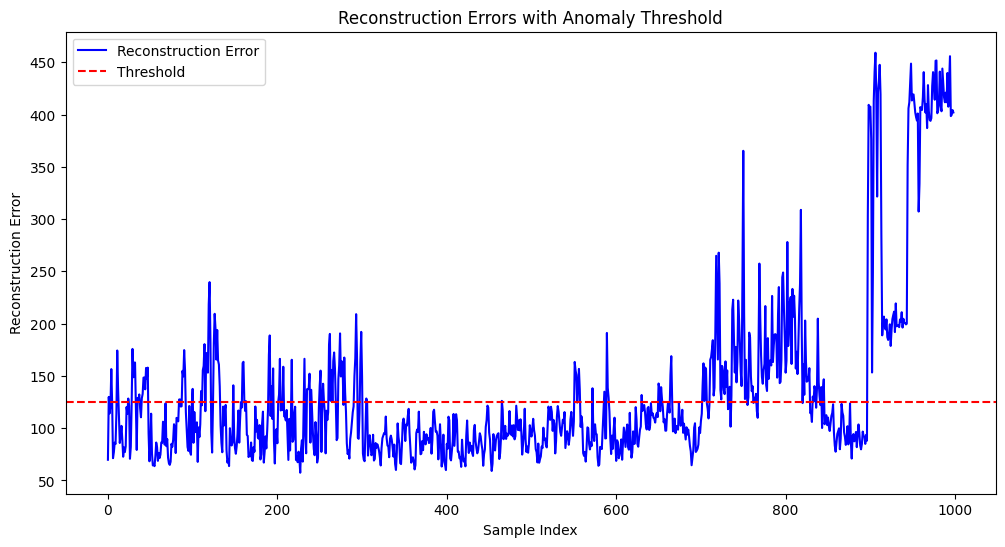

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_reconstruction_errors, label='Reconstruction Error', color='b')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Errors with Anomaly Threshold')
plt.legend()
plt.show()
